In [141]:
import numpy as np
import matplotlib.pyplot as plt

def load_fields(filename):
    """Load fields and coordinates from npz file."""
    data = np.load(filename)
    return data

field_latex = {
    "u_r": r"u_r",
    "u_theta": r"u_\theta",
    "u_phi": r"u_\phi",
    "B_r": r"B_r",
    "B_theta": r"B_\theta",
    "B_phi": r"B_\phi",
    "temperature": r"T"
}

def plot_equatorial(data, field_name, r, phi, theta, title="Equatorial slice", ax=None):
    eq_idx = np.argmin(np.abs(theta - np.pi/2))
    field = data[field_name][:, eq_idx, :]

    R, Phi = np.meshgrid(r, phi, indexing="ij")
    X, Y = R * np.cos(Phi), R * np.sin(Phi)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    im = ax.pcolormesh(X, Y, field, shading="auto", cmap="RdBu_r")
    ax.set_aspect("equal")
    ax.axis("off")
    label_str = field_latex.get(field_name, field_name)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(rf"${label_str}$", pad=10)

def plot_meridional(data, field_name, r, phi, theta, title="Meridional slice", ax=None):
    """
    Plot a meridional slice (half-circle) of the field at mid-phi.
    """
    mid_phi = np.argmin(np.abs(phi - np.pi/2)) #phi=pi/2
    field = data[field_name][:, :, mid_phi]  # shape (len(r), len(theta))

    R, Theta = np.meshgrid(r, theta, indexing="ij")
    X, Z = R * np.sin(Theta), R * np.cos(Theta)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    im = ax.pcolormesh(X, Z, field, shading="auto", cmap="RdBu_r")
    ax.set_aspect("equal")
    ax.axis("off")

    # LaTeX label mapping
    label_str = field_latex.get(field_name, field_name)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(rf"${label_str}$", pad=10)


def plot_cmb(data, field_name, r, phi, theta, title="CMB", ax=None):
    field = data[field_name][-1, :, :]
    lon, lat = phi - np.pi, np.pi/2 - theta
    Lon, Lat = np.meshgrid(lon, lat, indexing="ij")

    if ax is None:
        fig = plt.figure(figsize=(8,5))
        ax = fig.add_subplot(111, projection="mollweide")
    im = ax.pcolormesh(Lon, Lat, field.T, shading="auto", cmap="RdBu_r")
    ax.set_axis_off()
    label_str = field_latex.get(field_name, field_name)
    plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.05)



/var/folders/pl/b3wzjx65651cxv694q80qgxc0000gn/T/ipykernel_69119/2071256262.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(X, Y, field, shading="auto", cmap="RdBu_r")


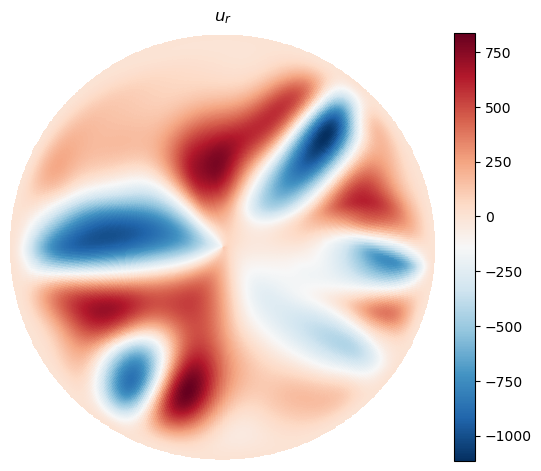

In [147]:
# Load data
data = load_fields("vis_fields.npz")

r = data["r"]
theta = data["theta"]
phi = data["phi"]

#example usage
plot_equatorial(data,'u_r', r, phi, theta)

/var/folders/pl/b3wzjx65651cxv694q80qgxc0000gn/T/ipykernel_69119/2071256262.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(X, Y, field, shading="auto", cmap="RdBu_r")
/var/folders/pl/b3wzjx65651cxv694q80qgxc0000gn/T/ipykernel_69119/2071256262.py:47: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(X, Z, field, shading="auto", cmap="RdBu_r")


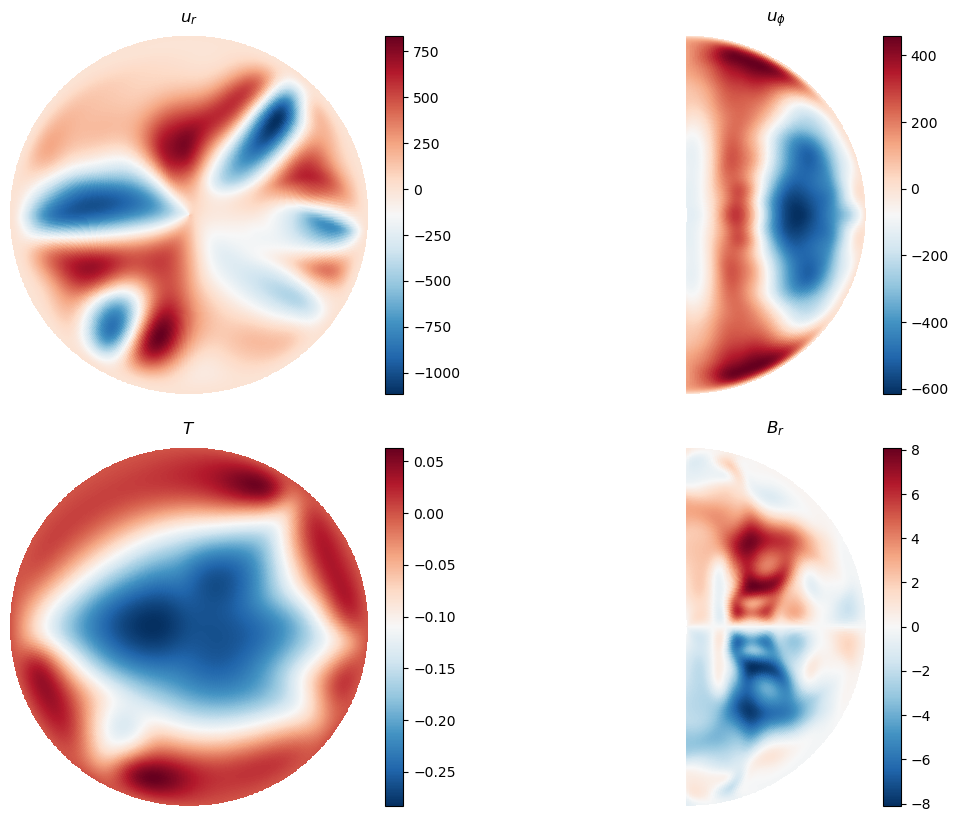

In [150]:
import matplotlib.pyplot as plt

# Load once
data = np.load("vis_fields.npz")

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, wspace=0.15, hspace=0.15)

# equatorial slice
ax0 = fig.add_subplot(gs[0,0])
plot_equatorial(data, "u_r", r, phi, theta, ax=ax0)

ax1 = fig.add_subplot(gs[0,1])
plot_meridional(data, "u_phi", r, phi, theta, ax=ax1)


ax2 = fig.add_subplot(gs[1,0])
plot_equatorial(data, "T", r, phi, theta, ax=ax2)

ax3 = fig.add_subplot(gs[1,1])
plot_meridional(data, "B_r", r, phi, theta, ax=ax3)

plt.show()


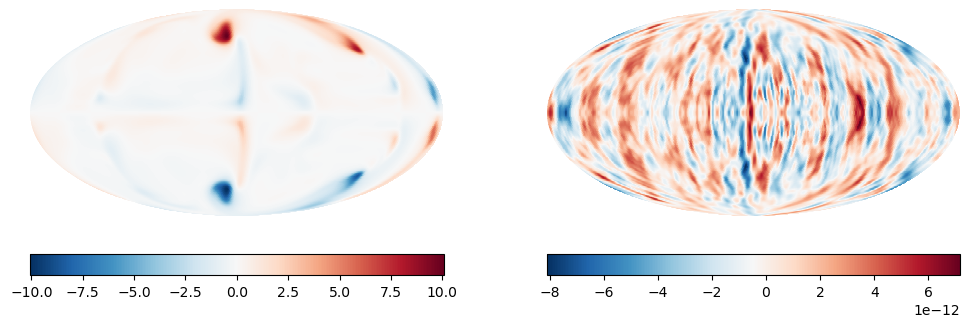

In [151]:

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(1, 2, wspace=0.25, hspace=0.3)

# CMB Mollweide
ax0 = fig.add_subplot(gs[0,0], projection="mollweide")
ax1 = fig.add_subplot(gs[0,1], projection="mollweide")

plot_cmb(data, "B_r", r, phi, theta,  ax=ax0)
plot_cmb(data, "u_phi", r, phi, theta, ax=ax1)

